# Penguins dataset

### 1. Import libraries and load data.

In [1]:
# 1. import libraries 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid') # optional: set visual style for seaborn plots

# 2. load 'penguins' dataset
df = sns.load_dataset('penguins')

### 2. Initial data inspection: inspect strucutre, dimensions, and contents of the dataset.

In [2]:
# 3. check first 5 rows
df.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# 4. view shape (rows, columns) and datatypes

print(f"Dataset Shape: {df.shape}\n")
df.info()

Dataset Shape: (344, 7)

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
# 5. view summary statistics for categorical features
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
# 6. view summary statistics for categorical features
df.describe(include=['str', 'object', 'category']) # when this cell is run, 'species', 'island', 'sex' are shown because they're non-numerical data

,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


### 3. Handle missing values

The `penguins` dataset contains some missing values (NaNs).

In [6]:
# 7. count missing values per column
print(df.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [7]:
# 7. drop rows with missing values for clean visualization
df_clean = df.dropna().copy() # drops null rows first, then creates independent copy of the cleaned data so that changes later on applied won't be also applied to original df

print(f"Cleaned dataset shape: {df_clean.shape}")

Cleaned dataset shape: (333, 7)


1. When to drop rows?
   - When there's a tiny fraction of the dataset that has msisisng values (like dropping 11 rows out of 344 in the `penguins` dataset). It will not distort the dataset or hurt statistical accuracy
   - Data is missing purely due to random chance
   - When building ML model to predict specific output. We cannot train on empty/null records
   - Avoid seaborn and matplotlib warnings or prevent them from behaving unpredictably. 
2. When not to drop rows?
    - high percentage of missing data
    - small overall sample size (if dataset has 50 rows, losing 5 rows severely distorts the statistics)
    - if values are missing for a specific reason

### 4. Univariate Analysis (Exploring Single Variables)
Examine individual feature distributions.

- countplot()
- histplot()

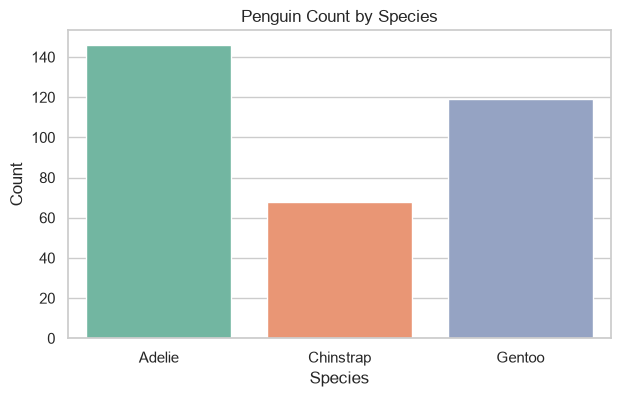

In [8]:
# 8. Categorical distribution: count by species using countplot. We only use 'species' variable here.

plt.figure(figsize=(7, 4)) # creating canvas for plotting

sns.countplot(data=df_clean, x='species', hue = 'species', palette='Set2') # set chart

# aesthetics
plt.title('Penguin Count by Species')
plt.xlabel('Species')
plt.ylabel('Count')

# show plot
plt.show()

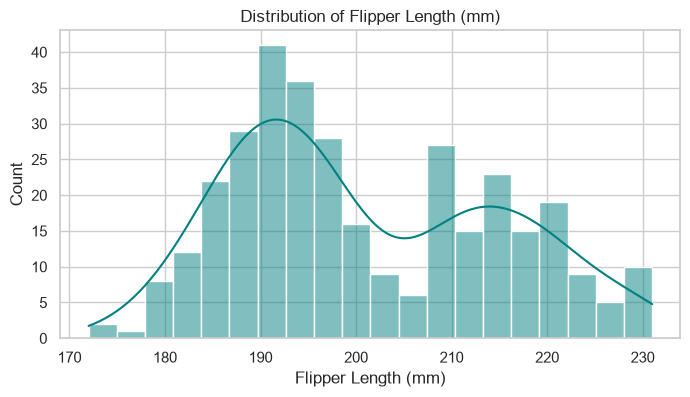

In [9]:
# 9. Numerical distribution: flipper length histogram. We only use 'flipper_length_mm' here.

plt.figure(figsize=(8, 4)) # setting canvas for plot 

sns.histplot(data=df_clean, x='flipper_length_mm', kde=True, color='teal', bins=20) # set chart
# kde=True -> produces smooth curve, representing distribution of data points

plt.title('Distribution of Flipper Length (mm)')
plt.xlabel('Flipper Length (mm)')

plt.show()

### 5. Bivariate Analysis (Exploring Relationships)
Compare relationships between continuous and categorical features.
- boxplot()
- scatterplot()

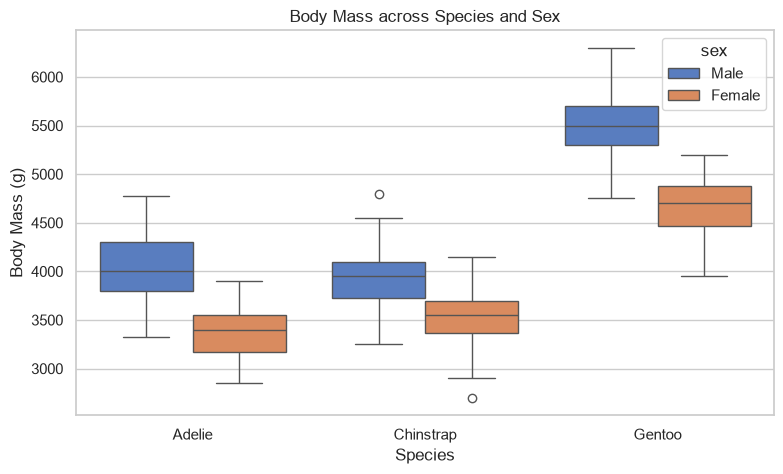

In [10]:
# 10. Boxplot comparing mass across species and sex. We use the variables 'species', 'body_mass_g' and 'sex' here.

plt.figure(figsize=(9,5)) # set canvas

sns.boxplot(data=df_clean, x='species', y='body_mass_g', hue = 'sex', palette='muted') # set chart

plt.title('Body Mass across Species and Sex')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')

plt.show()

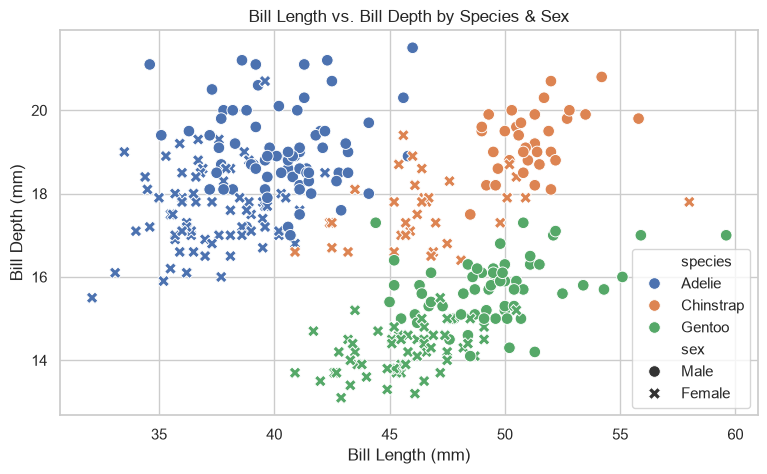

In [11]:
# 11. Scatterplot showing species clusters. We use the variables 'bill_length_mm' and 'bill_depth_mm here'.

plt.figure(figsize=(9,5)) # set canvas


sns.scatterplot(
    data=df_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    style='sex',
    s=70
)

plt.title('Bill Length vs. Bill Depth by Species & Sex')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')

plt.show()

### 6. Pairplot & Feature Correlations

Use pairplots and correlation heatmaps to spot patterns accross all numeric variables at once. 

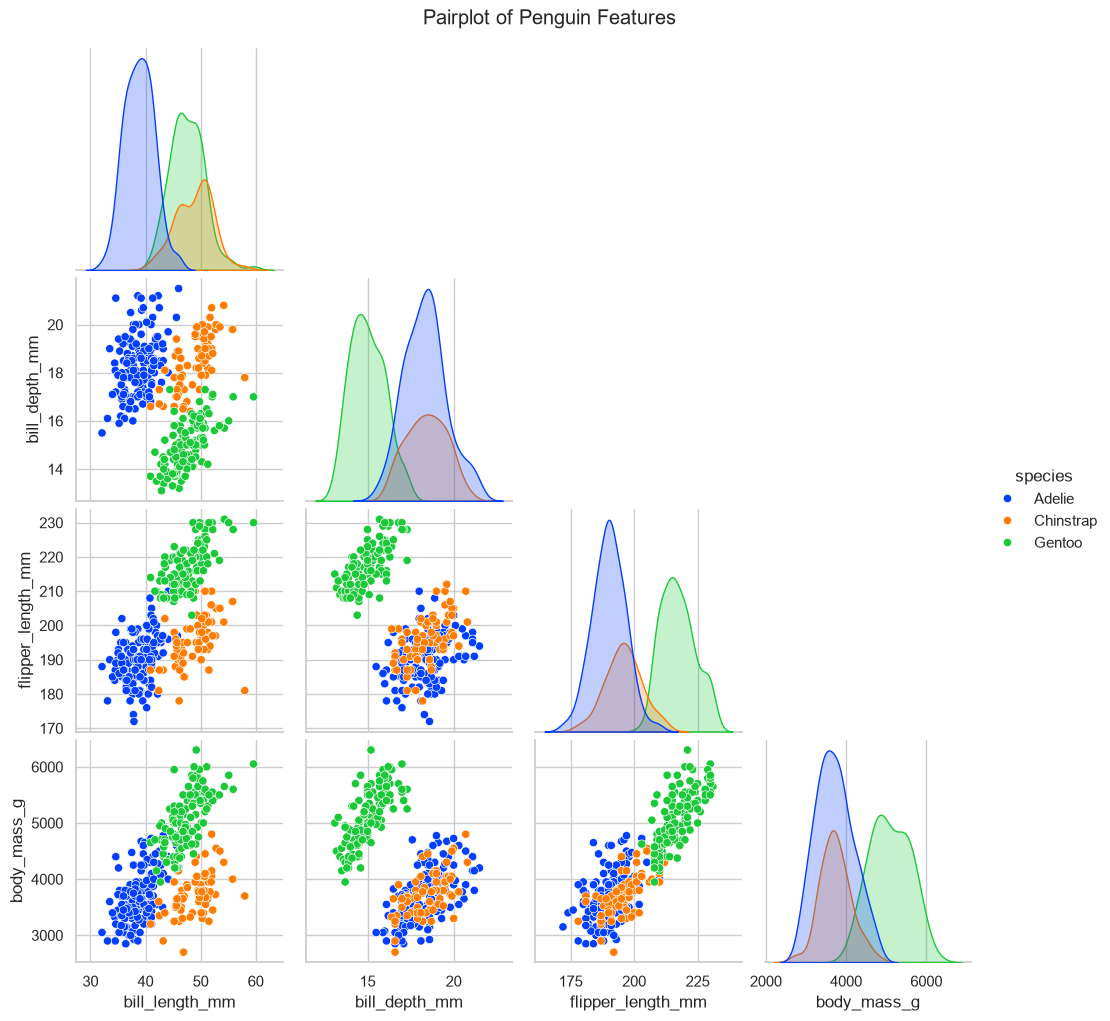

In [12]:
# 12. Pairplot color-coded by species
sns.pairplot(df_clean, hue='species', corner=True, palette='bright')
plt.suptitle('Pairplot of Penguin Features', y=1.02)

plt.show()

1. How to read pairplot? A pairplot creates a grid of small subplots showing pairwise relationships for every numerical variable in your dataset.
    - Off-Diagonal Plots (Scatter Plots): You look at these scatter plots to evaluate trends (positive, negative, non-linear) and clustering.
    - Diagonal Plots (Histogram/KDE Curves): Displays univariate distribution for that single column
    - Color grouping (hue parameter): when you add hue = 'species', all points and distribution curves get color-coded by category. If color groups overlap completely on a plot, that feature doesn't separate the classes well. If the color clusters form distint groups, that feature pair is a strong predictor of classification. 
    
2. When to use pairplot? Generate at the beginning of the EDA phase. 
    - Works best if dataset has 3 to 8 numerical features
    - When you want to see how target categories (like penguin species or tumor types) segment across all continuous variables simultaneously.
    - Right before applying classification or clustering algorithms to visualize natural grouping in your raw data.

3. Why is it important to use this?
    - Instead of using sns.scatterplot() individually for numerical columns, using sns.pairplot(df) visualizes the entire numerical structure of the dataset at once.
    - Reveals curved trends, U-shapes, clusters, and outliers that numerical summary statistics miss
    - Shows how features interact in combination

4. What can we do with this information? You can take immedicate analytical and data-preprocessing steps after.
    - select features for clarification: we can identify feature pairs that create clean boundaries between groups to prioritize them in ML models
    - detect outliers: can spot lone data points 
    - identify data transformation needs: look at the diagonal distributions; if a feature's distribution is heavily skewed, you know to apply transformations (like np.log()) before modeling [PERTAINING TO HISTOGRAMS]
    - isolate group anomalies 

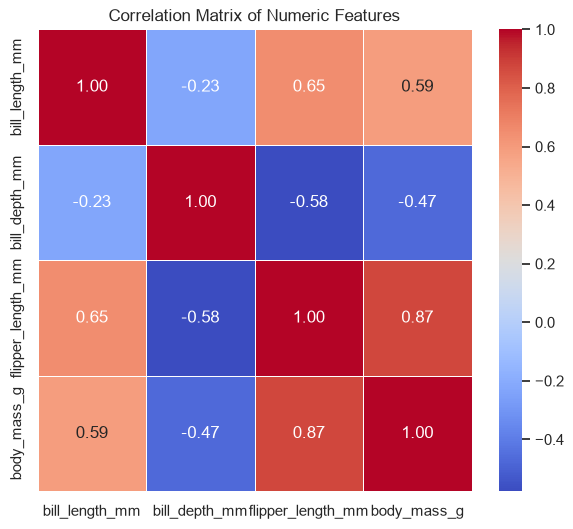

In [13]:
# 13. Compute and plot correlation matrix
plt.figure(figsize=(7, 6)) # set canvas

numeric_df = df_clean.select_dtypes(include=['float64', 'int64']) # only select numeric values
correlation_matrix = numeric_df.corr() # correlation

# set matrix with heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Numeric Features")
plt.show()

1. How to read correlation heatmap?
This displays the Person Correlation Coefficient between all numerical variable pairs in a grid format. Scale range is strictly from -1.0 to +1.0. 
    - Positive values (0 to +1.0): As one variable goes up, the other tends to go up. +1.0 is a perfect positive line. 
    - Negative values (-1.0 to 0): As one variable goes up, the other goes down. -1.0 is a perfect negative line. 
    - Zero (0.0): No linear relationship exists between the variables. 
    - The diagonal line (1.0): The diagonal from top-left to bottom-right always equals 1.0 because every variable is perfectly correlated with itself.

For colors, heatmaps use color gradient scales (e.g., coolwarm). Warm/dark colors usually represent strong positive values, while cool/opposite colors indicate negative values.
        
2. When to use?
Use it for EDA phase:
    - Multivariate exploration: when you have a dataset with multiple numerical variables and what to spot key relationships quickly.
    - Before feature selection: right before building machine learning models (like linear or logistic regression) to filter down variables
    - Check data health: to detech potential data issues like Multicollinearity (when two predictor variables are extremely highly correlated, e.g., r > 0.9).
   
3. What can we do with this information after generating heatmap?
Once generated, you can:
    - Drive further bivariate plots: use the heatmap to pick which variable pairs deserved detailed scatterplots or regression plots
    - Remove redundant features (feature reduction): if two input features share a near-perfect correlation (e.g., 0.98), one can often be dropped to simplify the dataset without losing information
    - Feature engineering: create composite features out of highly correlated variables (e.g., combining bill_length and bill_depth into a single bill ratio)
    - uncover anomalies/hidden patterns: identify unexpected zeros or weak correlations where you have intuitively expected a strong relationship (.e.g, investigating Simpson's Paradox)
      
4. Importance of this?
It gives you a data-backed direction on what factors drive your target outcome (e.g., discovering which customer behaviors correlate most strongly with sales revenue or churn).

### Summary of Findings

- Gento penguins are noticeably larger in body mass and flipper length compared to Adelie and Chinstrap. See boxplot: Body Mass & Flipper Length Distributions.
- Flipper length and body mass have a strong positive correlation. See correlation matrix of numeric features/pairplot.
- Bill depth and bill length separate the species clearly (Simpson's Paradox example: overall relationship appears negative, but within individual species, it is positive). See scatterplot: Bill length vs. Bill Depth by Species & Sex